# VGG19

Publikacje:
 - https://www.robots.ox.ac.uk/~vgg/publications/2015/Simonyan15/simonyan15.pdf?utm_source=chatgpt.com
 - https://www.researchgate.net/publication/346425175_Correlated_Time-Series_in_Multi-Day-Ahead_Streamflow_Forecasting_Using_Convolutional_Networks
 - https://ieeexplore.ieee.org/abstract/document/10551185
 - Znaleźć coś o transfer learning

## Data preparation

(128, 128, 3)
0.09


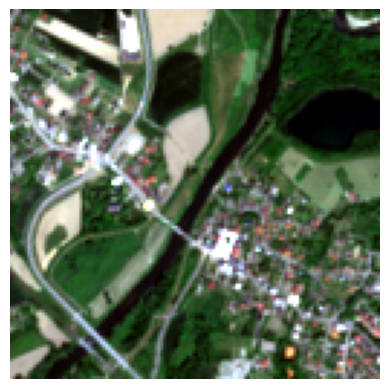

In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

df = pd.read_csv("df_final.csv")
row = df.iloc[0]

chunk = np.load(f'images/images_chunk_00{row['chunk_id']}.npy')
image = chunk[int(row["chunk_id"])]

rgb_image = image[:, :, 1:4]

print(rgb_image.shape)
print(row["flow"])

plt.imshow(rgb_image)
plt.axis("off")
plt.show()

### Split train/test sets

In [12]:
df = pd.read_csv("df_final.csv")
df.head()

,date,flow,chunk_id,id_in_chunk
0,2015-08-10,0.09,0,343
1,2015-09-10,4.68,2,458
2,2015-08-10,0.22,3,318
3,2015-08-17,0.22,3,317
4,2015-11-25,1.12,1,364


In [17]:
df['date'] = pd.to_datetime(df["date"])
df['year'] = df["date"].dt.year
df = df.sort_values("date").reset_index(drop=True)

train_df = df[df["year"] <= 2020].reset_index(drop=True)
val_df = df[df["year"] == 2021].reset_index(drop=True)
test_df = df[df["year"] == 2022].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 25240
Val: 6408
Test: 5444


TO DO: split data based on station_id (train based on one group of stations, tets on the other one)

### Transform data
